In [1]:
from keras import Sequential
from keras.layers import Dense, SimpleRNN

In [2]:
model = Sequential()

model.add(SimpleRNN(3, input_shape=(4, 5)))
model.add(Dense(1, activation="sigmoid"))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 3)              │            27 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31 (124.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

In [3]:
print(model.get_weights()[0].shape)
model.get_weights()[0]

(5, 3)


array([[-0.60696816,  0.37317163,  0.11392695],
       [-0.3774546 ,  0.7753323 , -0.44141588],
       [-0.75962883,  0.4558019 ,  0.18214804],
       [ 0.02566689,  0.10571414,  0.07965577],
       [ 0.27922446,  0.74441737,  0.5422165 ]], dtype=float32)

In [4]:
print(model.get_weights()[1].shape)
model.get_weights()[1]

(3, 3)


array([[ 0.5729718 , -0.59749585,  0.56098306],
       [ 0.5468312 ,  0.78855133,  0.28135836],
       [ 0.61047435, -0.14555262, -0.77854705]], dtype=float32)

In [5]:
print(model.get_weights()[2].shape)
model.get_weights()[2]

(3,)


array([0., 0., 0.], dtype=float32)

In [6]:
print(model.get_weights()[3].shape)
model.get_weights()[3]

(3, 1)


array([[ 0.49317026],
       [-0.8550865 ],
       [-0.86671287]], dtype=float32)

In [7]:
print(model.get_weights()[4].shape)
model.get_weights()[4]

(1,)


array([0.], dtype=float32)

# Integer Encoding in SimpleRNN

In [8]:
import numpy as np

docs = [
    "we win again",
    "this is so holy",
    "someday someday maybe",
    "silver lining",
    "happiest moment of my life",
    "kill all people"
]

In [10]:
from tensorflow.keras.preprocessing.text import Tokenizer
tokenizer = Tokenizer(oov_token="<nothing>")

In [11]:
tokenizer.fit_on_texts(docs)

In [37]:
print(f'we have {len(tokenizer.word_index)} unique words in our vocab')

we have 20 unique words in our vocab


In [12]:
tokenizer.word_index

{'<nothing>': 1,
 'someday': 2,
 'we': 3,
 'win': 4,
 'again': 5,
 'this': 6,
 'is': 7,
 'so': 8,
 'holy': 9,
 'maybe': 10,
 'silver': 11,
 'lining': 12,
 'happiest': 13,
 'moment': 14,
 'of': 15,
 'my': 16,
 'life': 17,
 'kill': 18,
 'all': 19,
 'people': 20}

In [13]:
tokenizer.word_counts

OrderedDict([('we', 1),
             ('win', 1),
             ('again', 1),
             ('this', 1),
             ('is', 1),
             ('so', 1),
             ('holy', 1),
             ('someday', 2),
             ('maybe', 1),
             ('silver', 1),
             ('lining', 1),
             ('happiest', 1),
             ('moment', 1),
             ('of', 1),
             ('my', 1),
             ('life', 1),
             ('kill', 1),
             ('all', 1),
             ('people', 1)])

In [14]:
tokenizer.document_count

6

In [15]:
seqs = tokenizer.texts_to_sequences(docs)
seqs

[[3, 4, 5],
 [6, 7, 8, 9],
 [2, 2, 10],
 [11, 12],
 [13, 14, 15, 16, 17],
 [18, 19, 20]]

In [16]:
from keras.utils import pad_sequences

In [17]:
seqs = pad_sequences(seqs, padding='post')

In [18]:
seqs

array([[ 3,  4,  5,  0,  0],
       [ 6,  7,  8,  9,  0],
       [ 2,  2, 10,  0,  0],
       [11, 12,  0,  0,  0],
       [13, 14, 15, 16, 17],
       [18, 19, 20,  0,  0]], dtype=int32)

## Sentiment Analysis for imdb

In [19]:
from keras.datasets import imdb
from keras import Sequential
from keras.layers import Dense, SimpleRNN, Embedding, Flatten

In [20]:
(X_train, y_train), (X_test, y_test) = imdb.load_data()

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [21]:
X_train.shape

(25000,)

In [22]:
print(len(X_train[0]))
print(len(X_train[1]))

218
189


In [23]:
X_train = pad_sequences(X_train, padding='post', maxlen=50) # maxlen argument is optional
X_test = pad_sequences(X_test, padding='post', maxlen=50) # maxlen argument is optional

In [24]:
print(len(X_train[0]))
print(len(X_train[1]))

50
50


In [25]:
X_train.shape

(25000, 50)

In [26]:
model = Sequential()

model.add(SimpleRNN(32, input_shape=(X_train.shape[1], 1), return_sequences=False))
model.add(Dense(1, activation='sigmoid'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,121 (4.38 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(X_train, y_train, epochs=32, validation_data=(X_test, y_test))

Epoch 1/32
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.5084 - loss: 0.6937 - val_accuracy: 0.5024 - val_loss: 0.6940
Epoch 2/32
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.5084 - loss: 0.6932 - val_accuracy: 0.5032 - val_loss: 0.6968
Epoch 3/32
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5066 - loss: 0.6930 - val_accuracy: 0.5063 - val_loss: 0.6937
Epoch 4/32
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.5052 - loss: 0.6931 - val_accuracy: 0.5066 - val_loss: 0.6951
Epoch 5/32
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5080 - loss: 0.6930 - val_accuracy: 0.5070 - val_loss: 0.6939
Epoch 6/32
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.5076 - loss: 0.6928 - val_accuracy: 0.5066 - val_loss: 0.6937
Epoch 7/32
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5078 - loss: 0.6931 - val_accuracy: 0.5081 - val_loss: 0.6938
Epoch 8/32
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.5096 - loss: 0.6927 - val_accuracy: 

## RNN Using Word Embeddings

In [38]:
# Number of unique words in our vocabulary (for imdb data)
vocab_size = 10000

In [41]:
from keras.layers import Input

model_2 = Sequential([
    Input(shape=(50,)),
    Embedding(input_dim=vocab_size, output_dim=2),
    SimpleRNN(32),
    Dense(1, activation='sigmoid')
])

model_2.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 50, 2)          │        20,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_4 (SimpleRNN)        │ (None, 32)             │         1,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,153 (82.63 KB)

 Trainable params: 21,153 (82.63 KB)

 Non-trainable params: 0 (0.00 B)

In [42]:
model_2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['acc'])
hist = model_2.fit(X_train, y_train, epochs=15, validation_data=(X_test, y_test))

Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - acc: 0.5423 - loss: 0.6867 - val_acc: 0.5180 - val_loss: 0.6847
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - acc: 0.6844 - loss: 0.5767 - val_acc: 0.7802 - val_loss: 0.4642
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - acc: 0.8236 - loss: 0.4008 - val_acc: 0.7951 - val_loss: 0.4437
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - acc: 0.8537 - loss: 0.3474 - val_acc: 0.7940 - val_loss: 0.4685
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - acc: 0.8623 - loss: 0.3292 - val_acc: 0.7870 - val_loss: 0.4737
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - acc: 0.8801 - loss: 0.2982 - val_acc: 0.7810 - val_loss: 0.5503
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - acc: 0.8929 - loss: 0.2753 - val_acc: 0.7667 - val_loss: 0.5353
Epoch 8/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - acc: 0.9011 - loss: 0.2583 - val_acc: 0.7729 - val_loss: 0.5595
Epoch 9/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step -

In [43]:
y_pred = model_2.predict(X_test)
y_pred = (y_pred > 0.5).astype(int).flatten()

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


In [44]:
import matplotlib.pyplot as plt
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             accuracy_score,
                             precision_score,
                             recall_score,
                             f1_score)
import seaborn as sns

In [45]:
cl_report = classification_report(y_test, y_pred)
conf_mat = confusion_matrix(y_test, y_pred)

In [46]:
print("Classification Report")
print(cl_report)

Classification Report
              precision    recall  f1-score   support

           0       0.73      0.78      0.76     12500
           1       0.77      0.72      0.74     12500

    accuracy                           0.75     25000
   macro avg       0.75      0.75      0.75     25000
weighted avg       0.75      0.75      0.75     25000



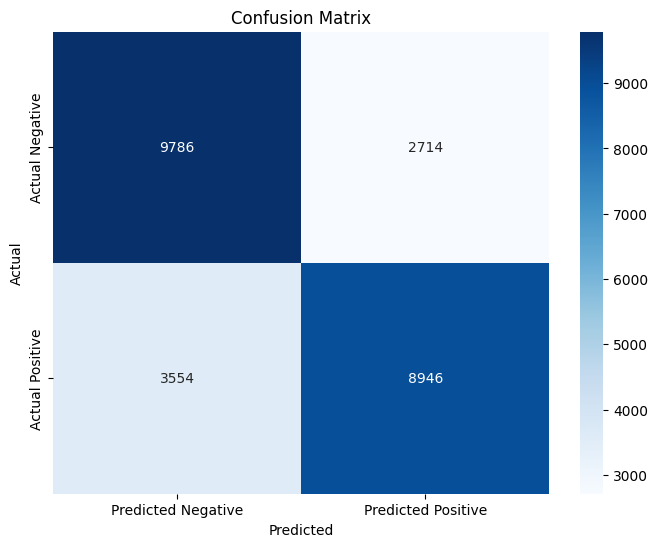

Accuracy: 0.75
Precision: 0.77
Recall: 0.72
F1-score: 0.74


In [47]:
# Plot confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat, annot=True, cmap='Blues', fmt='g',
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print metrics
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-score: {f1:.2f}")

In [48]:
from google.colab import output
output.eval_js('new Audio("https://upload.wikimedia.org/wikipedia/commons/0/05/Beep-09.ogg").play()')
